# Describe Cell Count in the Cell Painting Experiment

In [1]:
import pathlib
import pandas as pd

In [2]:
cell_count_dir = pathlib.Path("results")

cell_count_df = []
for file in cell_count_dir.iterdir():
    if "cell_count" in str(file):
        plate = file.name.split("_")[0]
        df = pd.read_csv(file, sep="\t").rename({plate: "cell_count"}, axis="columns")
        cell_count_df.append(df)
        
cell_count_df = pd.concat(cell_count_df)

print(cell_count_df.shape)
cell_count_df.head()

(3456, 6)


,Image_Metadata_Well,cell_count,gene_name,pert_name,broad_sample,cell_line
0,A01,4335,EMPTY,EMPTY,NaN,A549
1,A02,4129,MCL1,MCL1-5,NaN,A549
2,A03,4895,AKT1,AKT1-1,BRDN0001054908,A549
3,A04,4261,KRAS,KRAS-2B,NaN,A549
4,A05,4474,AKT1,AKT1-2,BRDN0001055115,A549


In [3]:
# Output a cell line by perturbation count file
pert_count_summary_df = (
    cell_count_df
    .groupby(["gene_name", "pert_name", "cell_line"])
    ["cell_count"]
    .sum()
    .reset_index()
)

output_file = pathlib.Path("tables/cell_count_summary.tsv")
pert_count_summary_df.to_csv(output_file, sep="\t", index=False)

pert_count_summary_df.sort_values(by="cell_count", ascending=False)

,gene_name,pert_name,cell_line,cell_count
147,EMPTY,EMPTY,A549,709899
149,EMPTY,EMPTY,HCC44,396359
148,EMPTY,EMPTY,ES2,357456
267,PPIB,PPIB-1,A549,104269
120,Chr2,Chr2-4,A549,101461
...,...,...,...,...
203,KIF11,KIF11-2,HCC44,3465
64,CCND1,CCND1-2,ES2,3021
200,KIF11,KIF11-1,HCC44,2748
202,KIF11,KIF11-2,ES2,2160


In [4]:
# Total number of cells
cell_count_df.cell_count.sum()

np.int64(8964210)

In [5]:
# Count cells by perturbation
cell_count_df.groupby("pert_name")["cell_count"].sum().sort_values(ascending=False)

pert_name
EMPTY      1463714
Chr2-4      211271
PPIB-1      209781
ORC4-1      200664
Chr2-5      199379
            ...   
ITGAV-1      27842
MYC-1        26297
ITGAV-2      24787
KIF11-1      19631
KIF11-2      18511
Name: cell_count, Length: 119, dtype: int64

In [6]:
# Cell count by cell line
cell_line_groupby = cell_count_df.groupby("cell_line")
cell_line_groupby["cell_count"].sum()

cell_line
A549     4318583
ES2      2182869
HCC44    2462758
Name: cell_count, dtype: int64

cell_line
A549     Axes(0.125,0.11;0.775x0.77)
ES2      Axes(0.125,0.11;0.775x0.77)
HCC44    Axes(0.125,0.11;0.775x0.77)
Name: cell_count, dtype: object

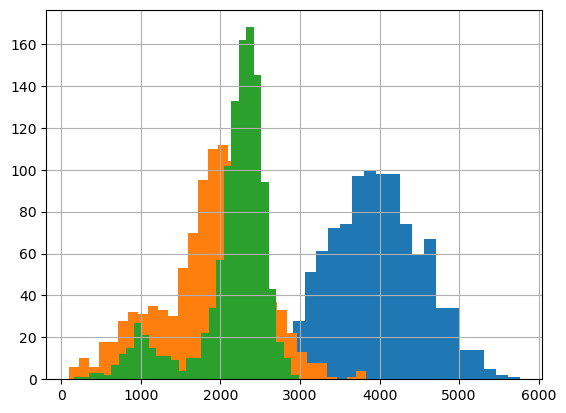

In [7]:
cell_line_groupby["cell_count"].hist(bins=30)

In [8]:
# Also, how many features?
profile_dir = pathlib.Path("data", "profiles")
for file in profile_dir.iterdir():
    plate = file.name
    plate_dir = pathlib.Path(profile_dir, plate)
    if plate != '.DS_Store':
        profile_file = plate_dir / f"{plate}.csv.gz"
        profile_df = pd.read_csv(profile_file)
        print(f"{plate}:")
        print(profile_df.shape)

SQ00014618:
(384, 1785)
SQ00014611:
(384, 1785)
SQ00014616:
(384, 1785)
SQ00014617:
(384, 1785)
SQ00014610:
(384, 1785)
SQ00014615:
(384, 1785)
SQ00014612:
(384, 1785)
SQ00014613:
(384, 1785)
SQ00014614:
(384, 1785)
